## Notebook to generate a new metadata json from a GNATSS config yaml


In [21]:
import os
from es_sfgtools.data_models.metadata.meta_io import config_yaml_to_siteconfig
from es_sfgtools.data_models.metadata.site import Site
import pandas as pd
from datetime import datetime, timedelta, timezone

In [14]:
yaml_path = os.path.expanduser('~/data/cascadia-gorda/NTH1/NTH1_2025_config.yaml')
site = config_yaml_to_siteconfig(yaml_path, 'NTH1', 'cascadia-gorda')

In [15]:
site.export_site(os.path.expanduser('~/data/cascadia-gorda/NTH1/NTH1.json'))

In [25]:
#determine surveys from community standard csv
csv_data = os.path.expanduser('~/data/cascadia-gorda/NTH1/gps_solution.csv')
df = pd.read_csv(csv_data)


In [30]:
j2000_epoch = datetime(2000, 1, 1, 12, 0, 0, tzinfo=timezone.utc)
df['datetime'] = pd.to_timedelta(df['T_transmit'],unit='s') + j2000_epoch
df

,MT_ID,TravelTime,T_transmit,X_transmit,Y_transmit,Z_transmit,T_receive,X_receive,Y_receive,Z_receive,ant_cov_XX0,ant_cov_XY0,ant_cov_XZ0,ant_cov_YX0,ant_cov_YY0,ant_cov_YZ0,ant_cov_ZX0,ant_cov_ZY0,ant_cov_ZZ0,ant_cov_XX1,ant_cov_XY1,ant_cov_XZ1,ant_cov_YX1,ant_cov_YY1,ant_cov_YZ1,ant_cov_ZX1,ant_cov_ZY1,ant_cov_ZZ1,datetime
0,NTH1-2,2.311764,808315235,-2741332.998,-3953326.440,4173624.386,8.083152e+08,-2741333.399,-3953325.092,4173624.271,0.01,0,0,0,0.01,0,0,0,0.01,0.01,0,0,0,0.01,0,0,0,0.01,2025-08-13 00:00:35+00:00
1,NTH1-3,2.624031,808315235,-2741332.998,-3953326.440,4173624.386,8.083152e+08,-2741333.523,-3953324.990,4173624.271,0.01,0,0,0,0.01,0,0,0,0.01,0.01,0,0,0,0.01,0,0,0,0.01,2025-08-13 00:00:35+00:00
2,NTH1-1,2.645811,808315235,-2741332.998,-3953326.440,4173624.386,8.083152e+08,-2741333.546,-3953324.974,4173624.271,0.01,0,0,0,0.01,0,0,0,0.01,0.01,0,0,0,0.01,0,0,0,0.01,2025-08-13 00:00:35+00:00
3,NTH1-2,2.263389,808315355,-2741388.928,-3953285.524,4173624.475,8.083154e+08,-2741390.872,-3953285.115,4173625.163,0.01,0,0,0,0.01,0,0,0,0.01,0.01,0,0,0,0.01,0,0,0,0.01,2025-08-13 00:02:35+00:00
4,NTH1-1,2.646932,808315355,-2741388.928,-3953285.524,4173624.475,8.083154e+08,-2741391.153,-3953285.158,4173625.195,0.01,0,0,0,0.01,0,0,0,0.01,0.01,0,0,0,0.01,0,0,0,0.01,2025-08-13 00:02:35+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11617,NTH1-2,2.497459,808964813,-2741111.740,-3953195.406,4173888.162,8.089648e+08,-2741113.827,-3953196.132,4173888.019,0.01,0,0,0,0.01,0,0,0,0.01,0.01,0,0,0,0.01,0,0,0,0.01,2025-08-20 12:26:53+00:00
11618,NTH1-3,2.613168,808964813,-2741111.740,-3953195.406,4173888.162,8.089648e+08,-2741113.958,-3953196.222,4173887.896,0.01,0,0,0,0.01,0,0,0,0.01,0.01,0,0,0,0.01,0,0,0,0.01,2025-08-20 12:26:53+00:00
11619,NTH1-1,2.365689,808964933,-2741146.108,-3953212.726,4173851.266,8.089649e+08,-2741146.751,-3953213.057,4173850.533,0.01,0,0,0,0.01,0,0,0,0.01,0.01,0,0,0,0.01,0,0,0,0.01,2025-08-20 12:28:53+00:00
11620,NTH1-2,2.463264,808964933,-2741146.108,-3953212.726,4173851.266,8.089649e+08,-2741146.779,-3953213.071,4173850.502,0.01,0,0,0,0.01,0,0,0,0.01,0.01,0,0,0,0.01,0,0,0,0.01,2025-08-20 12:28:53+00:00


In [36]:
def drop_outliers_by_std(df, column, threshold=3):
    """
    Removes rows from a DataFrame where a column's value is an outlier
    based on the number of standard deviations from the mean.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column (str): The name of the column to check for outliers.
        threshold (int or float): The number of standard deviations from the
                                   mean to use as the outlier threshold.

    Returns:
        pd.DataFrame: A new DataFrame with the outlier rows dropped.
    """
    # Calculate the mean and standard deviation of the specified column
    mean_val = df[column].mean()
    std_val = df[column].std()

    # Define the lower and upper bounds for the non-outlier range
    lower_bound = mean_val - (threshold * std_val)
    upper_bound = mean_val + (threshold * std_val)

    # Filter the DataFrame to keep only the rows within the bounds
    df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df_cleaned

<Axes: title={'center': 'X Positions from GPS Solutions'}, xlabel='X_transmit'>

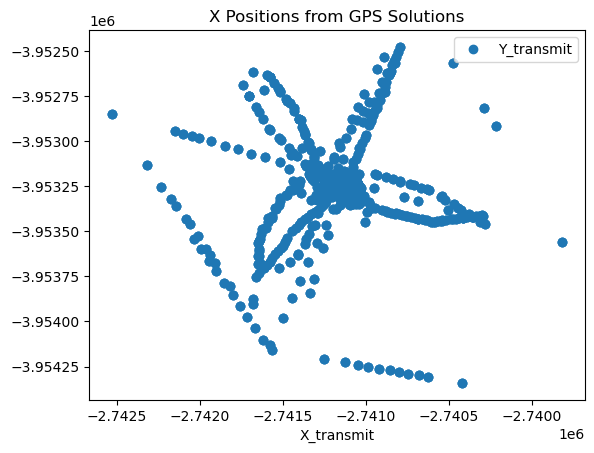

In [37]:
clean_df = drop_outliers_by_std(df, 'X_transmit', threshold=3)
clean_df.plot(x='X_transmit', y='Y_transmit', marker='o', linestyle='none', title='X Positions from GPS Solutions')

<Axes: title={'center': 'X Positions from GPS Solutions'}, xlabel='datetime'>

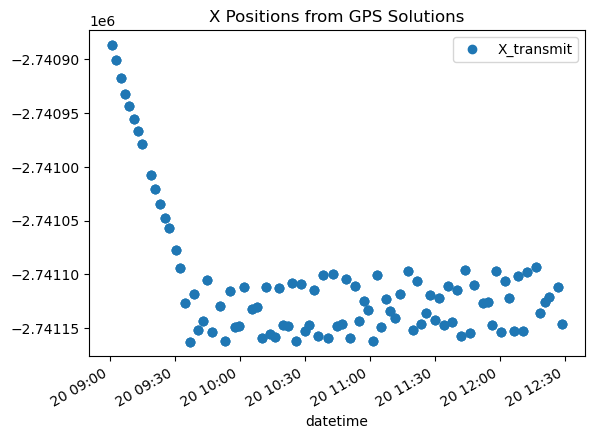

In [50]:
clean_df = drop_outliers_by_std(df, 'X_transmit', threshold=3)
start = datetime(2025, 8, 20, 9, tzinfo=timezone.utc)
end = datetime(2025, 8, 21, 9, tzinfo=timezone.utc)
mask = (clean_df['datetime'] >= start) & (clean_df['datetime'] <= end)
clean_df = clean_df.loc[mask]
clean_df.plot(x='datetime', y='X_transmit', marker='o', linestyle='none', title='X Positions from GPS Solutions')

In [53]:
site = Site.from_json(os.path.expanduser('~/data/cascadia-gorda/NTH1/NTH1.json'))
site.print_json()

{
  "names": [
    "NTH1"
  ],
  "networks": [
    "cascadia-gorda"
  ],
  "timeOrigin": "2025-08-13T00:00:00",
  "localGeoidHeight": 0.0,
  "arrayCenter": {
    "latitude": 41.13680833,
    "longitude": -124.73712071,
    "elevation": null
  },
  "campaigns": [
    {
      "name": "2025_A_1126",
      "type": "deploy",
      "vesselCode": "1126",
      "start": "2025-08-13T00:00:00",
      "end": "2025-08-20T12:30:00",
      "principalInvestigator": "Todd Erickson",
      "launchVesselName": null,
      "recoveryVesselName": null,
      "cruiseName": null,
      "technicianName": null,
      "technicianContact": null,
      "surveys": [
        {
          "id": "2025_A_1126_1",
          "type": "circle drive",
          "benchmarkIDs": [
            "NTH1-1",
            "NTH1-2",
            "NTH1-3"
          ],
          "start": "2025-08-13T00:00:00",
          "end": "2025-08-14T04:00:00",
          "notes": null,
          "commands": null
        },
        {
          "id": 